# KNN Exercise

![iris](assets/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available [here](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html).

## Task

1. Please import and pre-process the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance? 
If you can't it's because the original features are all on a very similar scale. Try multiplying one of the features by a factor of 10 and fitting the model to unscaled and scaled data. The difference should now be obvious 

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

In [27]:
# Step 1: Import and load the data
import numpy as np
import pandas as pd

# Read the iris data from the csv file in the data folder (same source as the offered solution)
df = pd.read_csv("data/iris.csv")

# Separate features (4 measurement columns, in cm) from the target (species name)
X = df.drop(columns="species")
y = df["species"]

# Inspect the data: shape, missing values, class balance
print(X.shape)
print(X.isna().sum())    # expect all 0 -> no cleaning needed
print(y.value_counts())  # expect 50 samples per class
X.head()

(150, 4)
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
# Step 2: Train/test split
from sklearn.model_selection import train_test_split

# Split features (X) and labels (y) into train and test sets
# train_size=0.5 -> 75 train rows, 75 test rows (small train set on purpose: iris is easily separable)
# shuffle=True   -> shuffle the rows before splitting
# stratify=y     -> keep the 3 classes equally represented in both sets
# random_state=123 fixes the shuffle, so the split is the same on every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=True, stratify=y, train_size=0.5, random_state=123
)

print(X_train.shape, X_test.shape)  # expect (75, 4) and (75, 4)
print(y_train.value_counts())       # expect 25 per class

(75, 4) (75, 4)
species
Iris-versicolor    25
Iris-setosa        25
Iris-virginica     25
Name: count, dtype: int64


Accuracy: 0.96
--------------------------------------------------


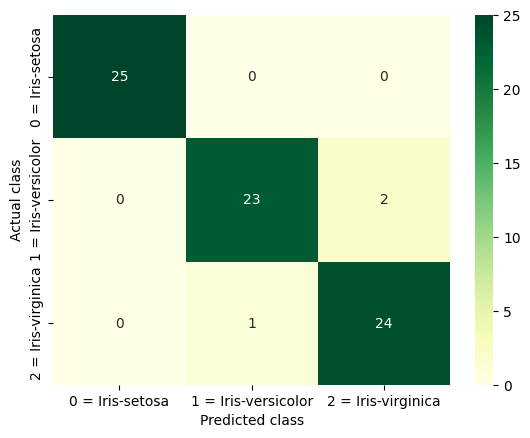

In [29]:
# Step 3: Fit KNN on the unscaled data, predict and evaluate
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


def fit_and_evaluate(X_tr, X_te, y_tr, y_te, k=5):
    """Fit a KNN model on the train data and return its accuracy on the test data."""
    # Create the model: each prediction is a majority vote of the k nearest neighbors
    # metric="euclidean" states the distance explicitly (it is also the default)
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")

    # "Fit" the model: KNN just stores the training data
    knn.fit(X_tr, y_tr)

    # Predict the class of every test row
    y_pred = knn.predict(X_te)

    # Compare predictions with the true labels
    acc = accuracy_score(y_te, y_pred)
    print("Accuracy:", round(acc, 2))
    print("-----" * 10)

    # Axis labels: "0 = Iris-setosa" etc. (knn.classes_ is in the same order as the matrix rows/columns)
    labels = [f"{i} = {name}" for i, name in enumerate(knn.classes_)]

    # Confusion matrix as heatmap (as in notebook 3):
    # rows = actual (true) class, columns = predicted class; off-diagonal cells are mistakes
    sns.heatmap(
        confusion_matrix(y_te, y_pred),
        annot=True,
        cmap="YlGn",
        xticklabels=labels,  # column labels: predicted classes
        yticklabels=labels,  # row labels: actual classes
    )
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.show()  # show the heatmap right away, so each call draws its own plot
    return acc


# Unscaled data (raw measurements in cm)
acc_unscaled = fit_and_evaluate(X_train, X_test, y_train, y_test)

Accuracy: 0.93
--------------------------------------------------


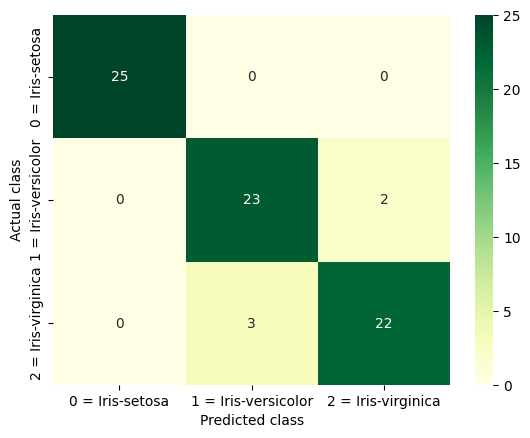

Unscaled: 0.960 | Scaled: 0.933


In [30]:
# Step 4: Scale the data and compare
from sklearn.preprocessing import StandardScaler

# Create the scaler: it rescales each feature to mean 0, standard deviation 1
scaler = StandardScaler()

# Learn mean and std from the TRAIN data only, then rescale the train data
X_train_scaled = scaler.fit_transform(X_train)

# Rescale the test data with the SAME mean and std learned from train (no refitting!)
X_test_scaled = scaler.transform(X_test)

# Same model and evaluation as in Step 3, now on scaled data
acc_scaled = fit_and_evaluate(X_train_scaled, X_test_scaled, y_train, y_test)

# Side-by-side comparison
print(f"Unscaled: {acc_unscaled:.3f} | Scaled: {acc_scaled:.3f}")

Accuracy: 0.8
--------------------------------------------------


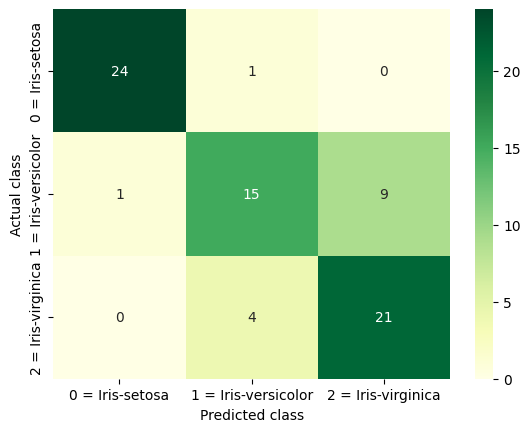

Accuracy: 0.93
--------------------------------------------------


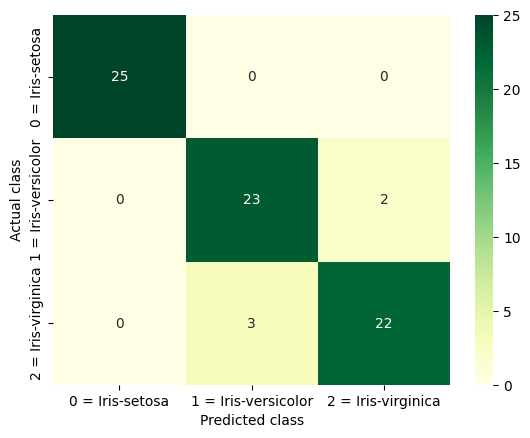

Original data    | unscaled: 0.960 | scaled: 0.933
Sepal length x10 | unscaled: 0.800 | scaled: 0.933


In [31]:
# Step 5: Multiply one feature by 10 and compare unscaled vs. scaled again

# Work on copies so the original X_train / X_test stay unchanged
X_train_big = X_train.copy()
X_test_big = X_test.copy()

# Multiply sepal length by 10 in BOTH sets, as if it were measured in mm instead of cm
X_train_big["sepal_length"] *= 10
X_test_big["sepal_length"] *= 10

# Unscaled: sepal length (numbers ~43-79) now dominates every distance
# -> this matches the first model of the offered solution (it inflates sepal_length before modelling)
acc_big_unscaled = fit_and_evaluate(X_train_big, X_test_big, y_train, y_test)

# Scaled: fit the scaler on train only, transform both sets (a fresh scaler, since the data changed)
scaler_big = StandardScaler()
X_train_big_scaled = scaler_big.fit_transform(X_train_big)
X_test_big_scaled = scaler_big.transform(X_test_big)

acc_big_scaled = fit_and_evaluate(X_train_big_scaled, X_test_big_scaled, y_train, y_test)

# Side-by-side summary of all four runs
print(f"Original data    | unscaled: {acc_unscaled:.3f} | scaled: {acc_scaled:.3f}")
print(f"Sepal length x10 | unscaled: {acc_big_unscaled:.3f} | scaled: {acc_big_scaled:.3f}")

# Conclusion: on the original data scaling changes little (all features are in cm).
# Once one feature has much bigger numbers, it dominates the distance and unscaled
# accuracy suffers; scaling removes the factor of 10 and restores the performance.